# AgDamage — Severity + Split (with cross-region OOD hold-out)

Pipeline: event-level severity (mean vs inverse-variance-weighted) → **carve a cross-region OOD
hold-out** → event-atomic, per-hazard quantile-stratified 6:2:2 split on the remainder → balance
check. The OOD hold-out (an *unseen region* per hazard, e.g. Sen1Floods11's Bolivia) is removed
**before** the train/val/test split so it never leaks in.

In [12]:
# ============================== CONFIG (edit) ==============================
from pathlib import Path
INPUT_PATHS       = ["/fs/ess/PGS0413/AgDamage_Benchmark_v2/Burnt/manifest.parquet"]   # CSV or Parquet manifest(s)
OUTPUT_DIR        = "out/burnt_severity_analysis_out_ootd"

# split-design knobs
K                 = 4
RATIOS            = (0.6, 0.2, 0.2)     # train : val : test (events, on the non-OOD remainder)
SAMPLES_PER_SHARD = 32
SEED              = 42

# severity knobs
DEFAULT_SIZE      = 512
MIN_CROPLAND_FRAC = 0.0
NEAR_ZERO_THRESH  = 0.01
SEVERITY_COL      = "severity_ivw"      # "severity_ivw" or "severity_mean"
NEAR_ZERO_GUARD   = False

# --- cross-region OOD hold-out ---
OOD_UNIT          = "country"           # geographic unit: "country" or "continent"
OOD_TARGET_FRAC   = 0.12                # aim ~10-15% of a hazard's events
OOD_MIN_EVENTS    = 30                  # floor for a usable OOD test set
OOD_BUFFER_KM     = 50                  # min separation from the training regions
OOD_REGIONS       = {}                  # decide after the research cell, e.g.
                                        #   {"Flood": ["Peru"], "Burnt": ["Benin"]}
                                        # empty = nothing held out yet (split uses all events)

SEVERITY_FIELD_BY_HAZARD = {
    "flood": "flooded_crop_frac", "burnt": "burned_crop_frac",
    "burned": "burned_crop_frac", "fire": "burned_crop_frac",
}

In [13]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
def _read(p):
    p=str(p); return pd.read_parquet(p) if p.endswith((".parquet",".pq")) else pd.read_csv(p)
df = pd.concat([_read(p) for p in INPUT_PATHS], ignore_index=True)
print(f"Loaded {len(df):,} chips | {df['event_id'].nunique():,} events | hazards: {sorted(df['hazard'].dropna().unique())}")
df.head()

Loaded 4,786 chips | 1,463 events | hazards: ['Burnt']


,chip_id,event_id,rank,source,tier,continent,country,place,event_date_start,event_date_end,...,burn_severity_mean,min_lon,min_lat,max_lon,max_lat,hazard,shard,has_s1,phenology_stage,qc_verdict
0,MC202000392449_r0065_c0134,MC202000392449,2,mcd64-cluster,A,Africa,Benin,Benin,2020-02-01,2020-02-28,...,2.64,2.581529,7.064411,2.627931,7.110764,Burnt,burnt-000100.tar,True,dormant,clean
1,MC202000392449_r0067_c0187,MC202000392449,5,mcd64-cluster,A,Africa,Benin,Benin,2020-02-01,2020-02-28,...,2.70,2.629526,7.062642,2.675923,7.108991,Burnt,burnt-000055.tar,True,dormant,clean
2,MC202000392449_r0079_c0239,MC202000392449,1,mcd64-cluster,A,Africa,Benin,Benin,2020-02-01,2020-02-28,...,3.04,2.676623,7.051822,2.723015,7.098167,Burnt,burnt-000115.tar,True,dormant,minor
3,MC202000392449_r0107_c0303,MC202000392449,4,mcd64-cluster,A,Africa,Benin,Benin,2020-02-01,2020-02-28,...,3.12,2.734593,7.026530,2.780977,7.072869,Burnt,burnt-000057.tar,True,dormant,clean
4,MC202000392449_r0130_c0205,MC202000392449,3,mcd64-cluster,A,Africa,Benin,Benin,2020-02-01,2020-02-28,...,2.93,2.645869,7.005666,2.692260,7.052014,Burnt,burnt-000034.tar,True,dormant,minor


In [14]:
# ---- infer missing `country` for groundsource chips from lat/lon (offline reverse geocoding) ----
# `continent` is already populated for every chip; only `country` is missing, and only for
# source=="groundsource" rows (the "dfo" rows already carry a hand-set country). Rather than asking
# the team to backfill it, do point-in-polygon lookup against a local Natural Earth 1:50m admin-0
# countries shapefile (downloaded once to naturalearth/, no network needed at run time — same
# offline-asset pattern as the vendored CROMA weights).
import geopandas as gpd

NE_COUNTRIES_SHP = "naturalearth/ne_50m_admin_0_countries.shp"

def infer_country_from_latlon(df, shp_path=NE_COUNTRIES_SHP):
    df = df.copy()
    need = df["country"].isna() & (df.get("source") == "groundsource")
    if "centroid_lon" in df.columns:
        clon, clat = df["centroid_lon"], df["centroid_lat"]
    else:
        clon, clat = (df["min_lon"] + df["max_lon"]) / 2, (df["min_lat"] + df["max_lat"]) / 2
    need &= clon.notna() & clat.notna()
    df["country_inferred"] = False
    if not need.any():
        return df

    countries = gpd.read_file(shp_path)[["NAME", "CONTINENT", "geometry"]]
    pts = gpd.GeoDataFrame({"idx": df.index[need]},
                            geometry=gpd.points_from_xy(clon[need], clat[need]), crs="EPSG:4326")

    joined = gpd.sjoin(pts, countries, how="left", predicate="within").drop_duplicates("idx").set_index("idx")
    unmatched = joined[joined["NAME"].isna()]
    if len(unmatched):
        # coastal points that miss every polygon at 1:50m resolution -> snap to nearest country
        pts_m = pts.set_index("idx").to_crs(3857)
        countries_m = countries.to_crs(3857)
        nearest = gpd.sjoin_nearest(pts_m.loc[unmatched.index, ["geometry"]], countries_m, how="left")
        nearest = nearest[~nearest.index.duplicated(keep="first")]
        joined.loc[nearest.index, "NAME"] = nearest["NAME"]

    df.loc[joined.index, "country"] = joined["NAME"]
    df.loc[joined.index, "country_inferred"] = joined["NAME"].notna()
    return df

df = infer_country_from_latlon(df)
n_inferred = int(df["country_inferred"].sum())
print(f"Inferred country for {n_inferred:,} groundsource chips from lat/lon "
      f"(offline Natural Earth 1:50m boundaries); "
      f"{int(df['country'].isna().sum()):,} chips still have no country "
      f"(missing/NaN centroid coordinates).")

Inferred country for 0 groundsource chips from lat/lon (offline Natural Earth 1:50m boundaries); 0 chips still have no country (missing/NaN centroid coordinates).


In [15]:
# ---- per-chip damage fraction (hazard-aware) + cropland pixel count + gate ----
def resolve_damage_frac(row):
    if "damage_frac" in df.columns and pd.notna(row.get("damage_frac")): return row["damage_frac"]
    fld=SEVERITY_FIELD_BY_HAZARD.get(str(row["hazard"]).lower())
    if fld and fld in df.columns and pd.notna(row.get(fld)): return row[fld]
    for f in ("flooded_crop_frac","burned_crop_frac","damaged_crop_frac"):
        if f in df.columns and pd.notna(row.get(f)): return row[f]
    return np.nan
df["damage_frac"]=df.apply(resolve_damage_frac,axis=1).astype(float)
size=df["size"] if "size" in df.columns else DEFAULT_SIZE
df["cropland_px"]=(df["cropland_frac"].astype(float)*(np.asarray(size)**2)).round()
gated=df[df["cropland_frac"].astype(float)>=MIN_CROPLAND_FRAC].copy()
print(f"Gate MIN_CROPLAND_FRAC={MIN_CROPLAND_FRAC}: kept {len(gated):,}/{len(df):,} chips")

Gate MIN_CROPLAND_FRAC=0.0: kept 4,786/4,786 chips


In [16]:
# ---- aggregate chips -> events: severity (mean & IVW) + geography + centroid ----
g=gated.dropna(subset=["damage_frac"]).copy()
g["w"]=g["cropland_px"].clip(lower=0); g["wf"]=g["w"]*g["damage_frac"]
if "centroid_lon" not in g.columns and {"min_lon","max_lon"}<=set(g.columns):
    g["centroid_lon"]=(g["min_lon"]+g["max_lon"])/2; g["centroid_lat"]=(g["min_lat"]+g["max_lat"])/2
for c in ("centroid_lon","centroid_lat"):
    if c not in g.columns: g[c]=np.nan
aggd={"n_chips":("damage_frac","size"),"severity_mean":("damage_frac","mean"),
      "_ws":("w","sum"),"_wf":("wf","sum"),"cropland_px":("cropland_px","sum"),
      "centroid_lon":("centroid_lon","mean"),"centroid_lat":("centroid_lat","mean")}
for col in ("country","continent"):
    if col in g.columns: aggd[col]=(col,"first")
events=g.groupby(["event_id","hazard"],as_index=False).agg(**aggd)
events["severity_ivw"]=np.where(events["_ws"]>0, events["_wf"]/events["_ws"], np.nan)
events=events.drop(columns=["_ws","_wf"])
events.to_csv(f"{OUTPUT_DIR}/event_severity.csv",index=False)
print(events.groupby("hazard")[["severity_mean","severity_ivw"]].describe().round(4).T)
events.head()

hazard                   Burnt
severity_mean count  1463.0000
              mean      0.3720
              std       0.2248
              min       0.0054
              25%       0.1902
              50%       0.3218
              75%       0.5405
              max       0.9851
severity_ivw  count  1463.0000
              mean      0.3806
              std       0.2240
              min       0.0054
              25%       0.1975
              50%       0.3384
              75%       0.5530
              max       0.9851


,event_id,hazard,n_chips,severity_mean,cropland_px,centroid_lon,centroid_lat,country,continent,severity_ivw
0,MC202000392449,Burnt,5,0.409780,639761.0,2.676825,7.065388,Benin,Africa,0.427849
1,MC202000946606,Burnt,4,0.432875,784597.0,124.243416,39.927715,"Korea, North",EastAsia,0.455914
2,MC202000981039,Burnt,4,0.094325,298555.0,29.711889,-14.083055,Zambia,Africa,0.091779
3,MC202001003906,Burnt,2,0.647250,497706.0,39.138247,36.999715,Turkey,Europe,0.647733
4,MC202001224756,Burnt,5,0.846540,1256247.0,75.353536,30.776160,India,SouthAsia,0.846483


### Severity histograms (mean vs IVW), per hazard

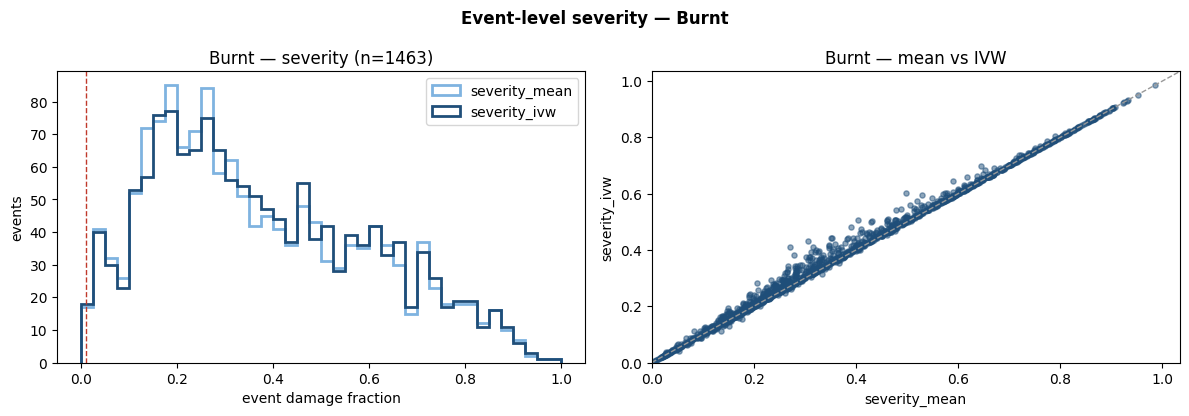

In [17]:
def compare_hist(hz,bins=40):
    d=events[events["hazard"].astype(str).str.lower()==hz.lower()]
    if d.empty: return
    fig,ax=plt.subplots(1,2,figsize=(12,4.2))
    for col,color in [("severity_mean","#7fb3e0"),("severity_ivw","#1f4e79")]:
        ax[0].hist(d[col].dropna(),bins=bins,range=(0,1),histtype="step",linewidth=2,color=color,label=col)
    ax[0].axvline(NEAR_ZERO_THRESH,color="#C0392B",ls="--",lw=1)
    ax[0].set_title(f"{hz} — severity (n={len(d)})"); ax[0].set_xlabel("event damage fraction")
    ax[0].set_ylabel("events"); ax[0].legend()
    ax[1].scatter(d["severity_mean"],d["severity_ivw"],s=14,alpha=0.5,color="#1f4e79")
    lim=[0,max(0.05,float(np.nanmax([d.severity_mean.max(),d.severity_ivw.max()]))*1.05)]
    ax[1].plot(lim,lim,color="#999",ls="--",lw=1); ax[1].set_xlim(lim); ax[1].set_ylim(lim)
    ax[1].set_xlabel("severity_mean"); ax[1].set_ylabel("severity_ivw"); ax[1].set_title(f"{hz} — mean vs IVW")
    fig.suptitle(f"Event-level severity — {hz}",fontweight="bold"); fig.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/hist_{hz.lower()}.png",dpi=120,bbox_inches="tight"); plt.show()
for hz in sorted(events["hazard"].dropna().unique()): compare_hist(hz)

## Research: rank candidate cross-region OOD hold-outs

For each hazard, aggregate events by `OOD_UNIT` and score each region on the three criteria:
**size** (enough events, ~10–15% of the hazard, not more), **representativeness** (Wasserstein of
its severity vs the rest — smaller = spans a similar minor→catastrophic range), and **isolation**
(min great-circle km from its events to all other events — larger = cleaner spatial separation).
A region is flagged `eligible` when it clears `OOD_MIN_EVENTS`, stays ≤20% of the hazard, and is at
least `OOD_BUFFER_KM` from the rest. Pick the eligible region with the smallest `repr_wass`.

In [18]:
# --- cross-region OOD hold-out ---
OOD_UNIT          = "country"           # geographic unit: "country" or "continent"
OOD_TARGET_FRAC   = 0.12                # aim ~10-15% of a hazard's events
OOD_MIN_EVENTS    = 20                  # floor for a usable OOD test set
OOD_BUFFER_KM     = 50                  # min separation from the training regions
OOD_REGIONS       = {}                  # decide after the research cell, e.g.
                                        #   {"Flood": ["Peru"], "Burnt": ["Benin"]}
                                        # empty = nothing held out yet (split uses all events)

def _haversine(lon1,lat1,lon2,lat2):
    R=6371.0; lon1,lat1,lon2,lat2=map(np.radians,[lon1,lat1,np.asarray(lon2,float),np.asarray(lat2,float)])
    d=np.sin((lat2-lat1)/2)**2+np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2
    return 2*R*np.arcsin(np.sqrt(d))
def _wass(a,b,n=1000):
    a=np.sort(np.asarray(a,float)); b=np.sort(np.asarray(b,float))
    if len(a)==0 or len(b)==0: return np.nan
    q=np.linspace(0,1,n); return float(np.mean(np.abs(np.quantile(a,q)-np.quantile(b,q))))

rows=[]
if OOD_UNIT in events.columns:
    for hz,dh in events.groupby("hazard"):
        tot=len(dh)
        for region,grp in dh.groupby(OOD_UNIT):
            rest=dh[dh[OOD_UNIT]!=region]
            iso=np.nan
            gg=grp.dropna(subset=["centroid_lon","centroid_lat"]); rr=rest.dropna(subset=["centroid_lon","centroid_lat"])
            if len(gg) and len(rr):
                iso=float(np.min([_haversine(r.centroid_lon,r.centroid_lat,rr["centroid_lon"].values,rr["centroid_lat"].values).min()
                                  for r in gg.itertuples()]))
            rows.append(dict(hazard=hz,region=region,
                continent=grp["continent"].iloc[0] if "continent" in grp else "",
                n_events=len(grp),frac_events=len(grp)/tot,n_chips=int(grp["n_chips"].sum()),
                sev_min=grp[SEVERITY_COL].min(),sev_max=grp[SEVERITY_COL].max(),
                repr_wass=_wass(grp[SEVERITY_COL],rest[SEVERITY_COL]),isolation_km=iso))
cand=pd.DataFrame(rows)
if len(cand):
    cand["eligible"]=((cand.n_events>=OOD_MIN_EVENTS)&(cand.frac_events<=0.20)&(cand.isolation_km.fillna(0)>=OOD_BUFFER_KM))
    cand=cand.sort_values(["hazard","eligible","repr_wass"],ascending=[True,False,True])
    cand.to_csv(f"{OUTPUT_DIR}/ood_candidates.csv",index=False)
    show=cand.round({"frac_events":3,"sev_min":3,"sev_max":3,"repr_wass":4,"isolation_km":1})
    try: display(show)
    except NameError: print(show.to_string(index=False))
    print("\nSuggested (eligible, most representative severity):")
    print(cand[cand.eligible].groupby("hazard").head(10)[["hazard","region","n_events","frac_events","repr_wass","isolation_km"]].to_string(index=False))
else:
    print(f"No '{OOD_UNIT}' column found — set OOD_UNIT to an available geographic column.")

,hazard,region,continent,n_events,frac_events,n_chips,sev_min,sev_max,repr_wass,isolation_km,eligible
9,Burnt,Brazil,SouthAmerica,112,0.077,342,0.018,0.790,0.0460,69.3,True
43,Burnt,Russia,Europe,20,0.014,50,0.038,0.833,0.0544,53.6,True
12,Burnt,Burma,SouthAsia,64,0.044,216,0.088,0.815,0.0614,190.4,True
36,Burnt,Mali,Africa,28,0.019,79,0.013,0.658,0.0882,81.3,True
17,Burnt,China,EastAsia,123,0.084,446,0.023,0.903,0.0943,393.2,True
...,...,...,...,...,...,...,...,...,...,...,...
1,Burnt,Algeria,Europe,1,0.001,4,0.101,0.101,0.2875,549.7,False
50,Burnt,Syria,Europe,5,0.003,19,0.463,0.788,0.2895,238.2,False
25,Burnt,Guatemala,NorthAmerica,1,0.001,1,0.634,0.634,0.2914,489.4,False
46,Burnt,Serbia,Europe,3,0.002,14,0.544,0.857,0.3012,215.9,False



Suggested (eligible, most representative severity):
hazard       region  n_events  frac_events  repr_wass  isolation_km
 Burnt       Brazil       112     0.076555   0.045989     69.275166
 Burnt       Russia        20     0.013671   0.054384     53.579386
 Burnt        Burma        64     0.043746   0.061373    190.413796
 Burnt         Mali        28     0.019139   0.088219     81.312881
 Burnt        China       123     0.084074   0.094307    393.166759
 Burnt     Ethiopia        30     0.020506   0.102605    133.265166
 Burnt       Turkey        32     0.021873   0.115781    143.545276
 Burnt       Angola        70     0.047847   0.179225    789.207755
 Burnt South Africa        22     0.015038   0.225658    843.678489


## Carve the OOD hold-out (before the split)

Set `OOD_REGIONS` above from the research table, then re-run from here. Events in a chosen region are
tagged `subset = "ood_holdout"` and excluded from the train/val/test split; everything else is `dev`.
With `OOD_REGIONS` empty, nothing is held out and the split uses all events.

In [23]:
OOD_REGIONS       =  {"burnt": ["South Africa"]}
# {"flooded": ["Philippines"]}                  # decide after the research cell, e.g.
                                        #   {"Flood": ["Peru"], "Burnt": ["South Africa"]}
events=events.drop(columns=["subset"],errors="ignore")
events["subset"]="dev"
for hz,regs in (OOD_REGIONS or {}).items():
    if OOD_UNIT in events.columns:
        m=(events["hazard"].astype(str).str.lower()==hz.lower())&(events[OOD_UNIT].isin(list(regs)))
        events.loc[m,"subset"]="ood_holdout"
print(events.groupby(["hazard","subset"]).size().to_string())

hazard  subset     
Burnt   dev            1441
        ood_holdout      22


## Split — event-atomic, per-hazard quantile-stratified (on `dev` only)

Per hazard, cut `dev` events into `K` quantile bins on `SEVERITY_COL`, assign events within each
`(hazard, bin)` stratum to train/val/test in `RATIOS` (seeded). Event-atomic: every chip inherits its
event's split. OOD events keep `split = "ood_holdout"`.

In [24]:
rng=np.random.default_rng(SEED)
def quantile_bins(s,k,near_zero_guard=NEAR_ZERO_GUARD,nz=NEAR_ZERO_THRESH):
    lab=pd.Series(index=s.index,dtype=object); rest=s
    if near_zero_guard:
        m=s<nz; lab[m]="none"; rest=s[~m]
    if len(rest):
        lab[rest.index]=pd.qcut(rest,k,labels=[f"q{i+1}" for i in range(k)],duplicates="drop").astype(object)
    return lab
def _alloc(n,r):
    n_tr=int(round(n*r[0])); n_va=int(round(n*r[1])); n_te=n-n_tr-n_va
    if n_te<0: n_va+=n_te; n_te=0
    return n_tr,n_va,n_te

dev=events[events["subset"]=="dev"]
event_class,event_split={},{}
for hz,dh in dev.groupby("hazard"):
    labels=quantile_bins(dh[SEVERITY_COL],K)
    tmp=dh.assign(_cls=labels.values)
    for eid,cls in zip(tmp["event_id"],tmp["_cls"]): event_class[eid]=cls
    for cls,grp in tmp.groupby("_cls"):
        ids=grp["event_id"].tolist(); rng.shuffle(ids)
        n_tr,n_va,n_te=_alloc(len(ids),RATIOS)
        for i,e in enumerate(ids):
            event_split[e]="train" if i<n_tr else ("val" if i<n_tr+n_va else "test")
events["severity_class"]=events["event_id"].map(event_class)
events["split"]=events["event_id"].map(event_split)
events.loc[events["subset"]=="ood_holdout","split"]="ood_holdout"

keep=["event_id","severity_ivw","severity_mean","severity_class","subset","split"]
manifest=df.merge(events[keep],on="event_id",how="left")
manifest.to_parquet(f"{OUTPUT_DIR}/manifest_with_split.parquet",index=False)
manifest.to_csv(f"{OUTPUT_DIR}/manifest_with_split.csv",index=False)
print("events per split:\n",events["split"].value_counts(dropna=False).to_string())
print("\nchips per split:\n",manifest["split"].value_counts(dropna=False).to_string())

events per split:
 split
train          865
test           288
val            288
ood_holdout     22

chips per split:
 split
train          2822
val             953
test            940
ood_holdout      71


### Quantile bin ranges (what each `severity_class` spans, on `dev`)

In [25]:
def bin_ranges(s,k,near_zero_guard=NEAR_ZERO_GUARD,nz=NEAR_ZERO_THRESH):
    rows,rest=[],s
    if near_zero_guard:
        m=s<nz
        if m.any(): rows.append(("none",0.0,float(nz),int(m.sum())))
        rest=s[~m]
    if len(rest):
        _,edges=pd.qcut(rest,k,retbins=True,duplicates="drop")
        labels=[f"q{i+1}" for i in range(len(edges)-1)]
        counts=pd.qcut(rest,k,labels=labels,duplicates="drop").value_counts()
        for i,lab in enumerate(labels): rows.append((lab,float(edges[i]),float(edges[i+1]),int(counts.get(lab,0))))
    return pd.DataFrame(rows,columns=["severity_class","low","high","n_events"])
parts=[]
for hz,dh in dev.groupby("hazard"):
    r=bin_ranges(dh[SEVERITY_COL],K); r.insert(0,"hazard",hz); parts.append(r)
bin_range_table=pd.concat(parts,ignore_index=True)
bin_range_table["range"]=bin_range_table.apply(lambda x:f"[{x.low:.4f}, {x.high:.4f}]",axis=1)
bin_range_table.to_csv(f"{OUTPUT_DIR}/severity_bin_ranges.csv",index=False)
try: display(bin_range_table[["hazard","severity_class","range","n_events"]])
except NameError: print(bin_range_table[["hazard","severity_class","range","n_events"]].to_string(index=False))

,hazard,severity_class,range,n_events
0,Burnt,q1,"[0.0067, 0.2005]",361
1,Burnt,q2,"[0.2005, 0.3426]",360
2,Burnt,q3,"[0.3426, 0.5574]",360
3,Burnt,q4,"[0.5574, 0.9851]",360


### Balance check (Wasserstein) + leakage assertion → `split_summary.json`

In [26]:
import json
def wasserstein1d(a,b,n=1000):
    a=np.sort(np.asarray(a,float)); b=np.sort(np.asarray(b,float))
    if len(a)==0 or len(b)==0: return None
    q=np.linspace(0,1,n); return float(np.mean(np.abs(np.quantile(a,q)-np.quantile(b,q))))
summary={"seed":SEED,"ratios":list(RATIOS),"K":K,"severity_col":SEVERITY_COL,
         "ood_unit":OOD_UNIT,"ood_regions":OOD_REGIONS,"by_hazard":{},"leakage_check":{}}
for hz,dh in events.groupby("hazard"):
    ch=manifest[manifest["hazard"]==hz]
    parts={sp:dh[dh["split"]==sp][SEVERITY_COL].values for sp in ["train","val","test"]}
    summary["by_hazard"][hz]={
      "events":{sp:int((dh["split"]==sp).sum()) for sp in ["train","val","test","ood_holdout"]},
      "chips":{sp:int((ch["split"]==sp).sum()) for sp in ["train","val","test","ood_holdout"]},
      "ood_regions":sorted(dh[dh["subset"]=="ood_holdout"][OOD_UNIT].unique()) if OOD_UNIT in dh else [],
      "severity_class_counts":{sp:dh[dh["split"]==sp]["severity_class"].value_counts().to_dict() for sp in ["train","val","test"]},
      "wasserstein":{"train_vs_test":wasserstein1d(parts["train"],parts["test"]),
                      "train_vs_val":wasserstein1d(parts["train"],parts["val"]),
                      "val_vs_test":wasserstein1d(parts["val"],parts["test"])}}
ev_bad=events.groupby("event_id")["split"].nunique(); ch_bad=manifest.groupby("event_id")["split"].nunique()
leaked=sorted(set(ev_bad[ev_bad>1].index)|set(ch_bad[ch_bad>1].index))
summary["leakage_check"]={"events_in_multiple_splits":leaked,"passed":len(leaked)==0}
with open(f"{OUTPUT_DIR}/split_summary.json","w") as f: json.dump(summary,f,indent=2,default=str)
assert summary["leakage_check"]["passed"], f"LEAKAGE: {leaked[:10]}"
print("Event-atomic check PASSED.\n"); print(json.dumps(summary["by_hazard"],indent=2,default=str))

Event-atomic check PASSED.

{
  "Burnt": {
    "events": {
      "train": 865,
      "val": 288,
      "test": 288,
      "ood_holdout": 22
    },
    "chips": {
      "train": 2822,
      "val": 953,
      "test": 940,
      "ood_holdout": 71
    },
    "ood_regions": [
      "South Africa"
    ],
    "severity_class_counts": {
      "train": {
        "q1": 217,
        "q3": 216,
        "q4": 216,
        "q2": 216
      },
      "val": {
        "q2": 72,
        "q3": 72,
        "q1": 72,
        "q4": 72
      },
      "test": {
        "q3": 72,
        "q4": 72,
        "q1": 72,
        "q2": 72
      }
    },
    "wasserstein": {
      "train_vs_test": 0.005384143686980776,
      "train_vs_val": 0.009650339415498851,
      "val_vs_test": 0.010636897059433199
    }
  }
}


### How to use

1. Run through the **research** cell and read `ood_candidates.csv` — pick one eligible region per
   hazard (smallest `repr_wass`, adequate size, good isolation).
2. Set `OOD_REGIONS` in CONFIG (e.g. `{"Flood":["Peru"], "Burnt":["Benin"]}`) and re-run from the
   carve cell. Those events become the `ood_holdout` (cross-region OOD test) and are excluded from
   train/val/test.
3. `manifest_with_split.parquet` now carries both `subset` (`dev` / `ood_holdout`) and `split`
   (`train`/`val`/`test`/`ood_holdout`). Report the in-distribution test and the OOD hold-out
   separately.